<a href="https://colab.research.google.com/github/kendallfrederick/umud_challenge/blob/main/fasc_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_d2a760e9c0b21e8e5d2147e657f460d7"

import kagglehub

# Download latest version
path = kagglehub.competition_download('umud-challenge-muscle-architecture-in-ultrasound-data')

print("Path to competition files:", path)

100%|██████████| 2.56G/2.56G [00:23<00:00, 116MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data


In [ ]:
import glob
import os

base = "/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"

apo_imgs = sorted(glob.glob(base + "/apo_imgs_v1/**/*.tif", recursive=True))
apo_masks = sorted(glob.glob(base + "/apo_masks_v1/**/*.tif", recursive=True))

fasc_imgs = sorted(glob.glob(base + "/fasc_imgs_v1/**/*.tif", recursive=True))
fasc_masks = sorted(glob.glob(base + "/fasc_masks_v1/**/*.tif", recursive=True))

test_imgs = sorted(glob.glob(base + "/test_images_v2/**/*.tif", recursive=True))

print("apo images:", len(apo_imgs))
print("apo masks:", len(apo_masks))
print("fasc images:", len(fasc_imgs))
print("fasc masks:", len(fasc_masks))
print("test images:", len(test_imgs))

apo images: 1048
apo masks: 1048
fasc images: 2761
fasc masks: 2761
test images: 251


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation layer
# Height and width shift, brightness, and rotation as done in DL Track
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# Apply the same augmentation to both image and mask
def augment_image_mask(img, mask):
    # Combine image and mask along the channel dimension
    # Shape becomes: (batch, 512, 512, 2)
    combined = tf.concat([img, mask], axis=-1)

    # Apply the same random transformation to both
    combined = data_augmentation(combined, training=True)

    # Separate image and mask again
    img = combined[..., :1]
    mask = combined[..., 1:]

    # Make the mask binary again
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask

In [ ]:
IMG_SIZE = 512

def load_tiff_python(img_path, mask_path):
    img_path = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    img = load_img(img_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img).astype("float32") / 255.0

    mask = load_img(mask_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
    mask = img_to_array(mask).astype("float32") / 255.0
    mask = (mask > 0.5).astype("float32")

    return img, mask


def load_image_mask(img_path, mask_path):
    img, mask = tf.py_function(
        func=load_tiff_python,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )

    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    mask.set_shape((IMG_SIZE, IMG_SIZE, 1))

    return img, mask

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import load_img, img_to_array

# Splits data into 80% for training and 20% for validation
fas_train_imgs, fas_val_imgs, fas_train_masks, fas_val_masks = train_test_split(
    fasc_imgs,
    fasc_masks,
    test_size=0.2,
    random_state=42 # Makes the split reproducible
)

# How many images at a time
BATCH_SIZE = 8

#Creates a TensorFlow dataset from the image paths and mask paths
train_ds = tf.data.Dataset.from_tensor_slices((fas_train_imgs, fas_train_masks))
train_ds = train_ds.map(load_image_mask).shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((fas_val_imgs, fas_val_masks))
val_ds = val_ds.map(load_image_mask).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Augmented training dataset
train_ds_aug = train_ds.map(
    augment_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Dice coefficient measures how much the predicted mask overlaps with the true mask
# Higher Dice is better, with 1 meaning perfect overlap
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten the masks so we compare all pixels together
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    # Count the overlapping pixels between the true and predicted masks
    intersection = tf.reduce_sum(y_true * y_pred)

    # Compute Dice score
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


# Dice loss is the opposite of Dice score
# Lower Dice loss means better segmentation
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


# Combine binary crossentropy and Dice loss
# BCE helps with pixel-wise classification
# Dice helps with mask overlap
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return bce + dice

In [ ]:
# A convolutional block used throughout the U-Net.
# It applies two convolutional layers with ReLU activation.
def conv_block(x, filters):
    # First convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    # Second convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    return x

# Builds a U-Net model for binary image segmentation
def build_unet(input_shape=(512, 512, 1)):

    # Input layer (512x512 grayscale image)
    inputs = layers.Input(input_shape)

    # ---------------- Encoder ----------------
    # Extracts image features while reducing spatial resolution
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    # ---------------- Bottleneck ----------------
    # Deepest part of the network, where high-level features are learned
    bn = conv_block(p3, 256)

    # ---------------- Decoder ----------------
    # Reconstructs the segmentation mask by increasing image resolution

    # Upsample and combine with encoder features
    u3 = layers.UpSampling2D()(bn)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 32)


    # Output layer
    # Produces a single-channel probability map where each pixel
    # represents the probability of belonging to the target class
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c6)

    # Create and return the complete U-Net model
    return models.Model(inputs, outputs)

In [ ]:
fas_model = build_unet(input_shape=(512, 512, 1))

# Stop training if validation loss stops improving
# restore_best_weights=True keeps the best version of the model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

# Compile the model with the improved loss and Dice metric
fas_model.compile(
    optimizer="adam",
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef]
)

# Early stopping may stop it before 10 if it stops improving
history = fas_model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 348s 999ms/step - accuracy: 0.9967 - dice_coef: 0.0195 - loss: 1.0076 - val_accuracy: 0.9960 - val_dice_coef: 0.0545 - val_loss: 0.9695
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 278s 936ms/step - accuracy: 0.9957 - dice_coef: 0.0852 - loss: 0.9335 - val_accuracy: 0.9944 - val_dice_coef: 0.1399 - val_loss: 0.8851
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 273s 917ms/step - accuracy: 0.9959 - dice_coef: 0.0994 - loss: 0.9187 - val_accuracy: 0.9945 - val_dice_coef: 0.1434 - val_loss: 0.8845
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 273s 925ms/step - accuracy: 0.9958 - dice_coef: 0.1074 - loss: 0.9109 - val_accuracy: 0.9958 - val_dice_coef: 0.1279 - val_loss: 0.8969
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 268s 907ms/step - accuracy: 0.9960 - dice_coef: 0.1225 - loss: 0.8951 - val_accuracy: 0.9951 - val_dice_coef: 0.1708 - val_loss: 0.8557
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 266s 902ms/step - accuracy: 0.9958 - dice_coef: 0.1235 - loss: 0.8946 - val_accu

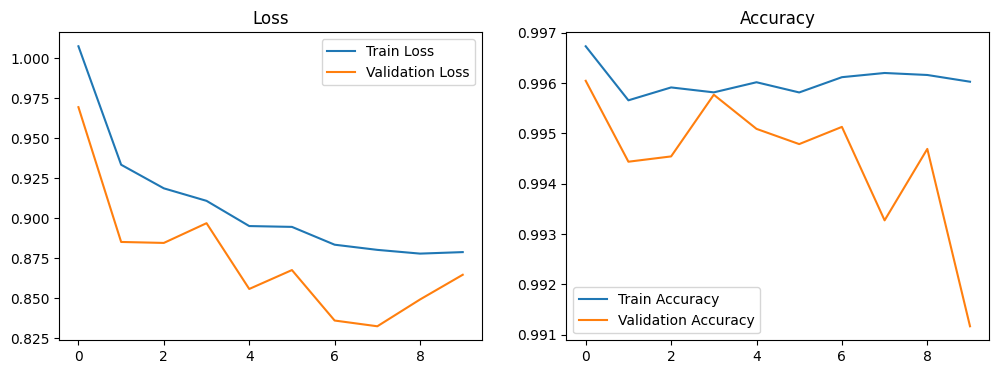

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.legend()

plt.show()

In [ ]:
# Save the already-trained model
fas_model.save("fasc_attention_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


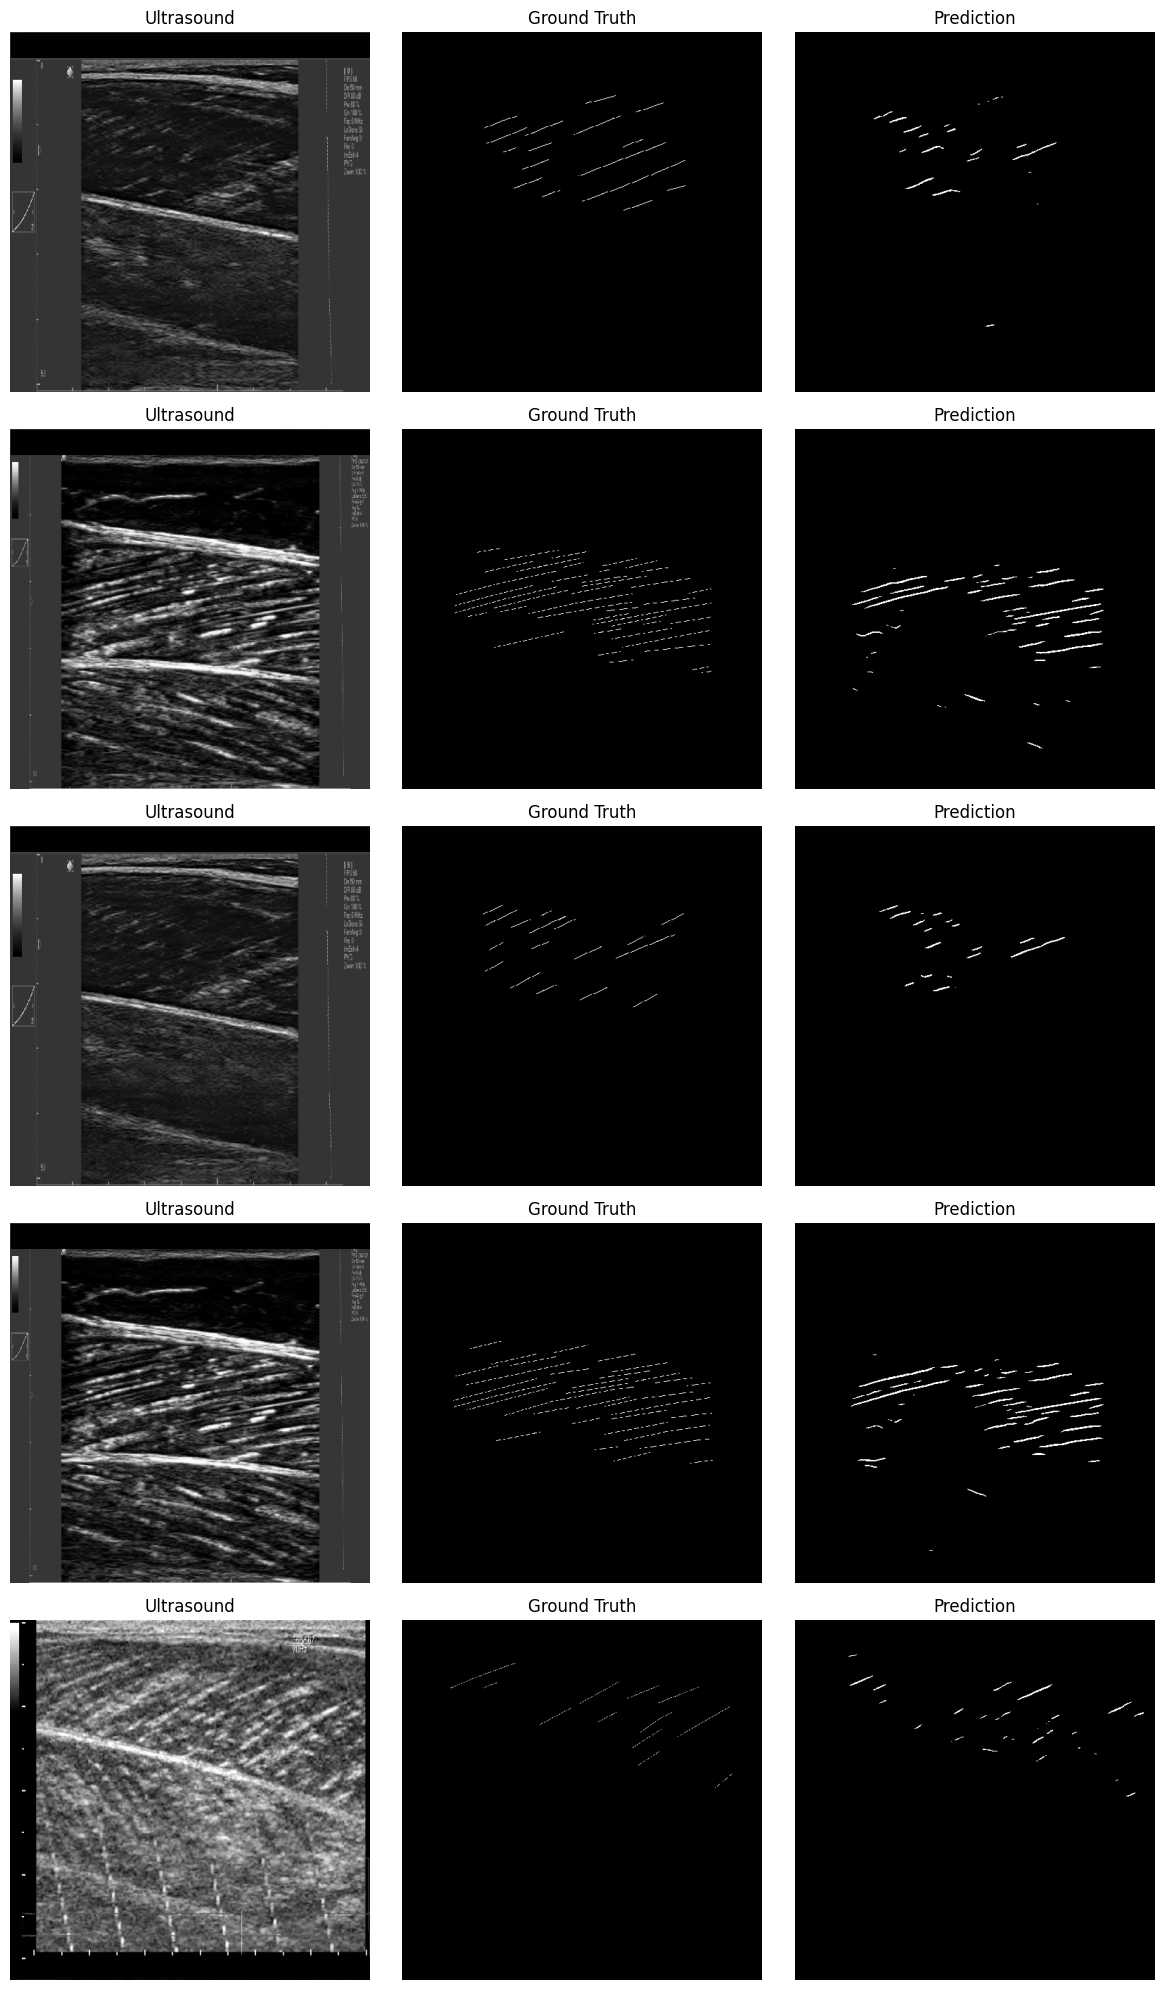

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the validation set
imgs, masks = next(iter(val_ds))

# Predict masks
preds = fas_model.predict(imgs)

# Convert probabilities to binary masks
preds = (preds > 0.5).astype(np.uint8)

# Number of images to display
num_images = min(5, len(imgs))

plt.figure(figsize=(12, 4 * num_images))

for i in range(num_images):

    # Original ultrasound
    plt.subplot(num_images, 3, 3*i + 1)
    plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
    plt.title("Ultrasound")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_images, 3, 3*i + 2)
    plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_images, 3, 3*i + 3)
    plt.imshow(preds[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()